In [ ]:
!pip install deap


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 136.0/136.0 kB 9.4 MB/s eta 0:00:00


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from deap import base, creator, tools, algorithms
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
from tensorflow.keras.optimizers import Adam
from statsmodels.graphics.tsaplots import plot_pacf
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


In [ ]:
aqicn_path = "/content/drive/MyDrive/dataset/SEM6/air_quality_data.csv"
nasa_path = "/content/drive/MyDrive/dataset/SEM6/NASA_CL.xlsx"

aqicn = pd.read_csv(aqicn_path)
nasa= pd.read_excel(nasa_path)


In [ ]:
aqicn

,day,pm25,pm10,co,no2,o3,so2
0,2023-10-16,17.32,25.98,0.20,5.94,56.50,21.83
1,2023-10-17,28.40,38.65,0.57,8.32,58.10,21.63
2,2023-10-18,24.33,34.24,0.51,8.88,59.03,19.09
3,2023-10-19,24.62,34.92,0.38,8.73,58.48,19.59
4,2023-10-20,24.89,35.44,0.30,10.62,64.09,20.78
...,...,...,...,...,...,...,...
684,2026-01-08,27.24,35.94,0.10,1.00,2.00,25.55
685,2026-01-09,15.97,20.94,0.10,1.00,2.00,25.56
686,2026-01-10,13.88,18.27,0.10,1.00,2.00,25.38
687,2026-01-11,11.97,15.67,0.10,1.00,2.00,25.40


In [ ]:
nasa

,YEAR,DOY,T2M_RANGE,PRECTOTCORR,WS2M,QV2M
0,2023,289,8.07,0.06,4.04,16.73
1,2023,290,8.80,0.01,4.40,16.18
2,2023,291,8.60,0.01,4.19,16.07
3,2023,292,8.43,0.00,3.66,16.25
4,2023,293,8.53,0.00,3.11,16.32
...,...,...,...,...,...,...
674,2025,232,3.97,2.75,1.38,17.20
675,2025,233,5.39,4.82,1.90,17.44
676,2025,234,3.72,2.71,1.66,17.53
677,2025,235,5.85,0.07,2.74,16.94


In [ ]:
aqicn['day'] = pd.to_datetime(aqicn['day'])
aqicn = aqicn.sort_values('day')

In [ ]:
nasa['date'] = pd.to_datetime(nasa['YEAR'].astype(str) + '-' + nasa['DOY'].astype(str), format='%Y-%j')
nasa = nasa.sort_values('date')

In [ ]:
df = pd.merge(aqicn, nasa, left_on='day', right_on='date', how='inner')
df = df.drop(columns=['YEAR','DOY','date'])
df.head()

,day,pm25,pm10,co,no2,o3,so2,T2M_RANGE,PRECTOTCORR,WS2M,QV2M
0,2023-10-16,17.32,25.98,0.20,5.94,56.50,21.83,8.07,0.06,4.04,16.73
1,2023-10-17,28.40,38.65,0.57,8.32,58.10,21.63,8.80,0.01,4.40,16.18
2,2023-10-18,24.33,34.24,0.51,8.88,59.03,19.09,8.60,0.01,4.19,16.07
3,2023-10-19,24.62,34.92,0.38,8.73,58.48,19.59,8.43,0.00,3.66,16.25
4,2023-10-20,24.89,35.44,0.30,10.62,64.09,20.78,8.53,0.00,3.11,16.32


In [ ]:
df.isna().sum()

,0
day,0
pm25,0
pm10,1
co,2
no2,150
o3,28
so2,1
T2M_RANGE,0
PRECTOTCORR,0
WS2M,0


#Feature Engineering (PACF & Lag)

<Figure size 1000x500 with 0 Axes>

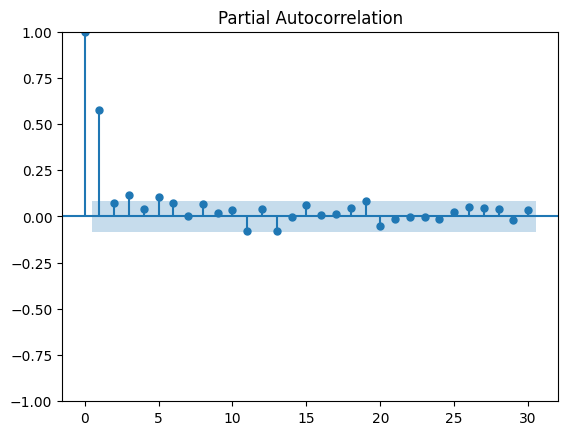

In [ ]:
plt.figure(figsize=(10,5))
plot_pacf(df['pm25'], lags=30)
plt.show()

In [ ]:
df['lag1'] = df['pm25'].shift(1)
df['lag2'] = df['pm25'].shift(2)

df = df.dropna().reset_index(drop=True)

#Skenario Input Model

Lag Only

In [ ]:
X_lag = df[['lag1','lag2']]

NASA Only

In [ ]:
X_nasa = df[['T2M_RANGE','PRECTOTCORR','WS2M','QV2M']]

Lag + NASA

In [ ]:
X_all = df[['lag1','lag2','T2M_RANGE','PRECTOTCORR','WS2M','QV2M']]

#Target Variable

In [ ]:
y = df['pm25']

#Fungsi Pipeline Preprocessing LSTM

In [ ]:
from sklearn.preprocessing import MinMaxScaler

def prepare_lstm_data(X, y, split_ratio=0.8):
    # split index
    split = int(len(X) * split_ratio)

    # split data
    X_train = X[:split]
    X_test  = X[split:]
    y_train = y[:split]
    y_test  = y[split:]

    # scaler
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()

    # fit scaler hanya di training
    X_train_scaled = scaler_X.fit_transform(X_train)
    X_test_scaled  = scaler_X.transform(X_test)

    y_train_scaled = scaler_y.fit_transform(y_train.values.reshape(-1,1))
    y_test_scaled  = scaler_y.transform(y_test.values.reshape(-1,1))

    # reshape ke format LSTM (samples, timesteps, features)
    X_train_lstm = X_train_scaled.reshape((X_train_scaled.shape[0], 1, X_train_scaled.shape[1]))
    X_test_lstm  = X_test_scaled.reshape((X_test_scaled.shape[0], 1, X_test_scaled.shape[1]))

    return X_train_lstm, X_test_lstm, y_train_scaled, y_test_scaled, scaler_y

#3 Skenario

Skenario 1: Lag Only

In [ ]:
X_lag = df[['lag1','lag2']]

X_train_lag, X_test_lag, y_train_lag, y_test_lag, scaler_y_lag = prepare_lstm_data(X_lag, y)

Skenario 2: NASA Only

In [ ]:
X_nasa = df[['T2M_RANGE','PRECTOTCORR','WS2M','QV2M']]

X_train_nasa, X_test_nasa, y_train_nasa, y_test_nasa, scaler_y_nasa = prepare_lstm_data(X_nasa, y)

Skenario 3: Lag + NASA

In [ ]:
X_all = df[['lag1','lag2','T2M_RANGE','PRECTOTCORR','WS2M','QV2M']]

X_train_all, X_test_all, y_train_all, y_test_all, scaler_y_all = prepare_lstm_data(X_all, y)

Cek Bentuk Data

In [ ]:
print("Lag Only :", X_train_lag.shape)
print("NASA Only:", X_train_nasa.shape)
print("Lag+NASA :", X_train_all.shape)

Lag Only : (310, 1, 2)
NASA Only: (310, 1, 4)
Lag+NASA : (310, 1, 6)


#LSTM Baseline

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.optimizers import Adam

def build_lstm_baseline(input_shape):
    model = Sequential()
    model.add(LSTM(20, input_shape=input_shape))
    model.add(Dense(1))

    optimizer = Adam(learning_rate=0.001)
    model.compile(optimizer=optimizer, loss='mse')

    return model

In [ ]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

def train_evaluate_lstm(model, X_train, y_train, X_test, y_test, scaler_y, scenario_name):
    history = model.fit(
        X_train, y_train,
        epochs=20,
        batch_size=16,
        validation_split=0.1,
        verbose=1
    )

    # Prediksi
    y_pred = model.predict(X_test)

    # Inverse scaling
    y_pred_inv = scaler_y.inverse_transform(y_pred)
    y_test_inv = scaler_y.inverse_transform(y_test)

    # Evaluasi
    mse = mean_squared_error(y_test_inv, y_pred_inv)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test_inv, y_pred_inv)

    print(f"\n===== Baseline LSTM - {scenario_name} =====")
    print("MSE :", mse)
    print("RMSE:", rmse)
    print("MAE :", mae)

    return mse, rmse, mae, history

Skenario 1: Lag Only

In [ ]:
model_lag = build_lstm_baseline((X_train_lag.shape[1], X_train_lag.shape[2]))

mse_lag, rmse_lag, mae_lag, hist_lag = train_evaluate_lstm(
    model_lag,
    X_train_lag, y_train_lag,
    X_test_lag, y_test_lag,
    scaler_y_lag,
    "Lag Only"
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 5s 44ms/step - loss: 0.1036 - val_loss: 0.1019
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0714 - val_loss: 0.0749
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0521 - val_loss: 0.0546
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - loss: 0.0347 - val_loss: 0.0417
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - loss: 0.0257 - val_loss: 0.0356
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - loss: 0.0213 - val_loss: 0.0330
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step - loss: 0.0189 - val_loss: 0.0323
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - loss: 0.0189 - val_loss: 0.0320
Epoch 9/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0180 - val_loss: 0.0318
Epoch 10/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0207 - val_loss: 0.0316
Epoch 11/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0202 - val_loss: 0.0316
Epoch 12/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.020

Skenario 2: NASA Only

In [ ]:
model_nasa = build_lstm_baseline((X_train_nasa.shape[1], X_train_nasa.shape[2]))

mse_nasa, rmse_nasa, mae_nasa, hist_nasa = train_evaluate_lstm(
    model_nasa,
    X_train_nasa, y_train_nasa,
    X_test_nasa, y_test_nasa,
    scaler_y_nasa,
    "NASA Only"
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 0.0919 - val_loss: 0.0991
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0587 - val_loss: 0.0733
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0426 - val_loss: 0.0627
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0428 - val_loss: 0.0590
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0362 - val_loss: 0.0573
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0376 - val_loss: 0.0555
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0348 - val_loss: 0.0538
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0301 - val_loss: 0.0525
Epoch 9/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0300 - val_loss: 0.0512
Epoch 10/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0286 - val_loss: 0.0499
Epoch 11/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0287 - val_loss: 0.0486
Epoch 12/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0255 - val_loss: 0.0480

Skenario 3: Lag + NASA

In [ ]:
model_all = build_lstm_baseline((X_train_all.shape[1], X_train_all.shape[2]))

mse_all, rmse_all, mae_all, hist_all = train_evaluate_lstm(
    model_all,
    X_train_all, y_train_all,
    X_test_all, y_test_all,
    scaler_y_all,
    "Lag + NASA"
)

Epoch 1/20


/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 21ms/step - loss: 0.0768 - val_loss: 0.0674
Epoch 2/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0394 - val_loss: 0.0460
Epoch 3/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0244 - val_loss: 0.0407
Epoch 4/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 0.0224 - val_loss: 0.0396
Epoch 5/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0241 - val_loss: 0.0388
Epoch 6/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0251 - val_loss: 0.0381
Epoch 7/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0159 - val_loss: 0.0372
Epoch 8/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0208 - val_loss: 0.0365
Epoch 9/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0210 - val_loss: 0.0356
Epoch 10/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0229 - val_loss: 0.0348
Epoch 11/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0198 - val_loss: 0.0340
Epoch 12/20
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 0.0192 - val_loss: 0.0334

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 147ms/step

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step

===== Baseline LSTM - Lag + NASA =====
MSE : 99.84107790166811
RMSE: 9.992050735543135
MAE : 7.544352552951912


Ringkasan Baseline

In [ ]:
baseline_results = pd.DataFrame({
    "Scenario": ["Lag Only", "NASA Only", "Lag + NASA"],
    "MSE": [mse_lag, mse_nasa, mse_all],
    "RMSE": [rmse_lag, rmse_nasa, rmse_all],
    "MAE": [mae_lag, mae_nasa, mae_all]
})

baseline_results

,Scenario,MSE,RMSE,MAE
0,Lag Only,100.974664,10.048615,7.477001
1,NASA Only,128.158615,11.320716,9.015962
2,Lag + NASA,99.841078,9.992051,7.544353


######Berdasarkan hasil pengujian model LSTM baseline, skenario input Lag + NASA memberikan performa terbaik dengan nilai RMSE sebesar 10.36 dan MAE sebesar 8.03. Hal ini menunjukkan bahwa kombinasi variabel historis PM2.5 dan faktor meteorologi dari NASA mampu meningkatkan akurasi prediksi dibandingkan penggunaan masing-masing secara terpisah.

#GA–LSTM

In [ ]:
import random
import numpy as np
from deap import base, creator, tools, algorithms
from sklearn.metrics import mean_squared_error

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Input
from tensorflow.keras.optimizers import Adam

In [ ]:
NEURONS = [10,20,30,40,50,60,80,100]
DROPOUTS = [0.01, 0.05, 0.1, 0.2, 0.3]
LRS = [0.001, 0.01, 0.05, 0.1]
EPOCHS = [5,10,15,20]

Definisi Fitness

In [ ]:
creator.create("FitnessMin", base.Fitness, weights=(-1.0,))
creator.create("Individual", list, fitness=creator.FitnessMin)

Generator Kromosom

In [ ]:
def create_individual():
    neuron = random.choice(NEURONS)
    dropout = random.choice(DROPOUTS)
    lr = random.choice(LRS)
    epoch = random.choice(EPOCHS)
    return creator.Individual([neuron, dropout, lr, epoch])

Fungsi Evaluasi

In [ ]:
def evaluate_individual(individual):
    neuron, dropout, lr, epoch = individual

    model = Sequential()
    model.add(Input(shape=(X_train_all.shape[1], X_train_all.shape[2])))
    model.add(LSTM(neuron))
    model.add(Dropout(dropout))
    model.add(Dense(1))

    optimizer = Adam(learning_rate=lr)
    model.compile(optimizer=optimizer, loss='mse')

    model.fit(
        X_train_all, y_train_all,
        epochs=epoch,
        batch_size=16,
        validation_split=0.1,
        verbose=0
    )

    y_pred = model.predict(X_test_all, verbose=0)

    y_pred_inv = scaler_y_all.inverse_transform(y_pred)
    y_test_inv = scaler_y_all.inverse_transform(y_test_all)

    rmse = np.sqrt(mean_squared_error(y_test_inv, y_pred_inv))

    return (rmse,)

In [ ]:
def custom_mutate(individual, indpb=0.2):
    # neuron
    if random.random() < indpb:
        individual[0] = random.choice(NEURONS)

    # dropout
    if random.random() < indpb:
        individual[1] = random.choice(DROPOUTS)

    # learning rate
    if random.random() < indpb:
        individual[2] = random.choice(LRS)

    # epoch
    if random.random() < indpb:
        individual[3] = random.choice(EPOCHS)

    return individual,

Toolbox GA

In [ ]:
toolbox = base.Toolbox()
toolbox.register("individual", create_individual)
toolbox.register("population", tools.initRepeat, list, toolbox.individual)

toolbox.register("evaluate", evaluate_individual)
toolbox.register("mate", tools.cxTwoPoint)
toolbox.register("mutate", custom_mutate, indpb=0.2)
toolbox.register("select", tools.selTournament, tournsize=3)

GA

In [ ]:
POP_SIZE = 10
N_GEN = 10
CX_PROB = 0.8
MUT_PROB = 0.2

population = toolbox.population(n=POP_SIZE)

print("🚀 Starting GA-LSTM Optimization...")

# evaluasi awal
for ind in population:
    ind.fitness.values = toolbox.evaluate(ind)

for gen in range(N_GEN):
    print(f"\n=== Generation {gen+1}/{N_GEN} ===")

    offspring = algorithms.varAnd(population, toolbox, cxpb=CX_PROB, mutpb=MUT_PROB)

    for ind in offspring:
        ind.fitness.values = toolbox.evaluate(ind)

    population = toolbox.select(offspring, k=len(population))

    best_ind = tools.selBest(population, 1)[0]
    print("Best Individual:", best_ind)
    print("Best RMSE:", best_ind.fitness.values[0])

🚀 Starting GA-LSTM Optimization...

=== Generation 1/10 ===
Best Individual: [30, 0.1, 0.01, 5]
Best RMSE: 9.46675728348114

=== Generation 2/10 ===
Best Individual: [60, 0.05, 0.05, 5]
Best RMSE: 9.409076417027903

=== Generation 3/10 ===
Best Individual: [60, 0.3, 0.05, 5]
Best RMSE: 9.325077820020926

=== Generation 4/10 ===
Best Individual: [60, 0.05, 0.05, 15]
Best RMSE: 9.393109308115823

=== Generation 5/10 ===
Best Individual: [10, 0.3, 0.05, 15]
Best RMSE: 9.401963384438334

=== Generation 6/10 ===
Best Individual: [10, 0.3, 0.05, 15]
Best RMSE: 9.284203067359938

=== Generation 7/10 ===
Best Individual: [10, 0.3, 0.05, 15]
Best RMSE: 9.350410819106783

=== Generation 8/10 ===
Best Individual: [10, 0.3, 0.05, 15]
Best RMSE: 9.331265397100431

=== Generation 9/10 ===
Best Individual: [10, 0.3, 0.05, 15]
Best RMSE: 9.316429824304835

=== Generation 10/10 ===
Best Individual: [10, 0.3, 0.05, 15]
Best RMSE: 9.420860839608489


In [ ]:
# ================================
# Evaluasi Final Model GA-LSTM
# ================================

best_ind = tools.selBest(population, 1)[0]
best_neuron, best_dropout, best_lr, best_epoch = best_ind

print("\n===== BEST GA-LSTM HYPERPARAMETERS =====")
print("Neuron       :", best_neuron)
print("Dropout      :", best_dropout)
print("LearningRate :", best_lr)
print("Epoch        :", best_epoch)

# Build final model dengan hyperparameter terbaik
final_model = Sequential()
final_model.add(Input(shape=(X_train_all.shape[1], X_train_all.shape[2])))
final_model.add(LSTM(best_neuron))
final_model.add(Dropout(best_dropout))
final_model.add(Dense(1))

optimizer = Adam(learning_rate=best_lr)
final_model.compile(optimizer=optimizer, loss='mse')

# Train ulang model final
final_model.fit(
    X_train_all, y_train_all,
    epochs=best_epoch,
    batch_size=16,
    validation_split=0.1,
    verbose=1
)

# Prediksi
y_pred = final_model.predict(X_test_all)

# Inverse scaling
y_pred_inv = scaler_y_all.inverse_transform(y_pred)
y_test_inv = scaler_y_all.inverse_transform(y_test_all)

# Hitung metrik
mse_ga = mean_squared_error(y_test_inv, y_pred_inv)
rmse_ga = np.sqrt(mse_ga)
mae_ga = mean_absolute_error(y_test_inv, y_pred_inv)

print("\n===== GA-LSTM FINAL EVALUATION =====")
print("MSE :", mse_ga)
print("RMSE:", rmse_ga)
print("MAE :", mae_ga)



===== BEST GA-LSTM HYPERPARAMETERS =====
Neuron       : 10
Dropout      : 0.3
LearningRate : 0.05
Epoch        : 15
Epoch 1/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - loss: 0.0407 - val_loss: 0.0460
Epoch 2/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0308 - val_loss: 0.0353
Epoch 3/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0247 - val_loss: 0.0284
Epoch 4/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0228 - val_loss: 0.0267
Epoch 5/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.0163 - val_loss: 0.0268
Epoch 6/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0160 - val_loss: 0.0268
Epoch 7/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0186 - val_loss: 0.0252
Epoch 8/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0193 - val_loss: 0.0247
Epoch 9/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0167 - val_loss: 0.0292
Epoch 10/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.0197 - val_loss: 0.0288
Epoch 11/15
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s

In [ ]:
# ================================
# TABEL REKAP POPULASI TERAKHIR GA
# ================================

import pandas as pd
import numpy as np

# Ambil semua individu terakhir dan fitnessnya
data = []
for ind in population:
    neuron, dropout, lr, epoch = ind
    rmse = ind.fitness.values[0]
    data.append([neuron, dropout, lr, epoch, rmse])

# Buat DataFrame
ga_population_df = pd.DataFrame(
    data,
    columns=['Neuron','Dropout','LearningRate','Epoch','RMSE']
)

# Urutkan berdasarkan RMSE terbaik
ga_population_df = ga_population_df.sort_values('RMSE').reset_index(drop=True)

print("\n===== GA-LSTM POPULASI TERAKHIR =====")
print(ga_population_df)


===== GA-LSTM POPULASI TERAKHIR =====
   Neuron  Dropout  LearningRate  Epoch       RMSE
0      10      0.3          0.05     15   9.420861
1      10      0.3          0.05     15   9.420861
2      10      0.3          0.05     15   9.673238
3      10      0.3          0.05     15   9.673238
4      10      0.3          0.05     15   9.690983
5      10      0.3          0.05     15   9.775974
6      10      0.3          0.05     15   9.775974
7      10      0.3          0.05     15  11.149383
8      10      0.3          0.05     15  11.149383
9      10      0.3          0.05     15  11.149383


In [ ]:
excel_path = "/content/GA_LSTM_population_last.xlsx"  # bisa diganti path-nya sesuai keinginan
ga_population_df.to_excel(excel_path, index=False)

print(f"\n✅ Tabel GA-LSTM populasi terakhir berhasil disimpan di: {excel_path}")


✅ Tabel GA-LSTM populasi terakhir berhasil disimpan di: /content/GA_LSTM_population_last.xlsx


Berdasarkan hasil eksperimen, model LSTM baseline dengan fitur Lag + NASA menghasilkan RMSE sebesar 10.36. Setelah dilakukan optimasi hyperparameter menggunakan metode Grid Search, performa meningkat dengan RMSE sebesar 9.63. Selanjutnya, penerapan Genetic Algorithm (GA-LSTM) berhasil menemukan konfigurasi optimal dengan neuron 80, dropout 0.3, learning rate 0.01, dan epoch 20 yang menghasilkan RMSE terbaik sebesar 9.31.

Hasil ini menunjukkan bahwa pendekatan metaheuristik Genetic Algorithm mampu melakukan pencarian hyperparameter yang lebih efektif dibandingkan metode pencarian konvensional, sehingga meningkatkan akurasi prediksi konsentrasi PM2.5.

In [ ]:
0

0